In [60]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Reading Data

In [61]:
df = pd.read_csv('Polynomial regression - Data.csv')

Data Inspection

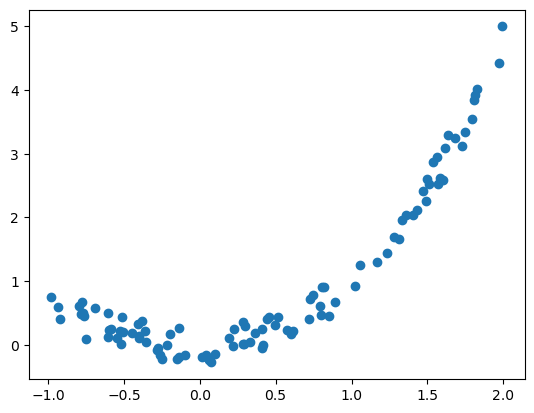

In [62]:
fig1, ax1 = plt.subplots(1)
x, y = df.x, df.y
N = df.shape[0]
ax1.plot(x, y, 'o')

Regression using Numpy

In [63]:
p = np.polynomial.polynomial.Polynomial.fit(x,y,2)
p.coef


array([0.2292344 , 1.79079342, 2.45928384])

Comparing the fitted model to the data:

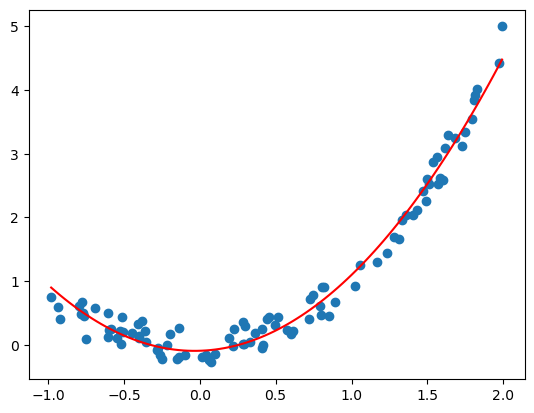

In [64]:
xrange = (min(x), max(x))
xs = np.linspace(*xrange, 100)
ys = p(xs)
ax1.plot(xs , ys, color = 'red')
fig1

Defining the MSE function

In [65]:
mse = lambda x, y : ((x-y)**2).mean()

In [66]:
print(mse(y, p(x)))

0.034132688492847924


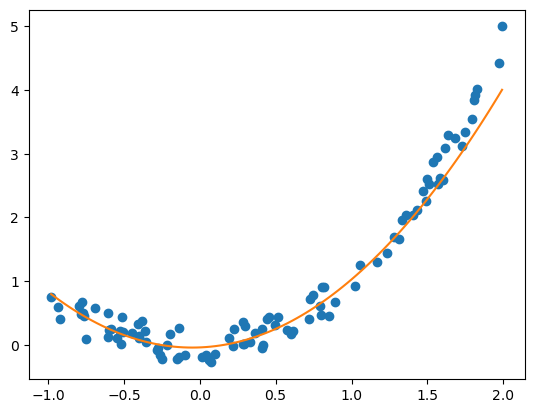

In [67]:
q = 80
Ntrn = N*q//100
xtrn, ytrn = x[:Ntrn], y[:Ntrn]
xtst, ytst = x[Ntrn:], y[Ntrn:]
ptrn = np.polynomial.polynomial.Polynomial.fit(xtrn,ytrn, 2)
fig2, ax2 = plt.subplots(1)
ax2.plot(x, y, 'o', xs, ptrn(xs))

In [68]:
print(mse(y[:Ntrn], ptrn(x[:Ntrn])))
print(mse(y[Ntrn:], ptrn(x[Ntrn:])))

0.02648111183490707
0.1887430127094339


In [69]:
def fit_model(x, y, m, qtr = 80):
    N = x.size
    mtrn = N*qtr//100
    p = np.polynomial.polynomial.Polynomial.fit(x[:mtrn], y[:mtrn], m)
    etrn = mse(y[:mtrn], p(x[:mtrn]))
    etst = mse(y[mtrn:], p(x[mtrn:]))
    return p, etrn, etst

So, for a 3rd order fit we write:

In [70]:
fit_model(x, y, 3)

(Polynomial([0.02868013, 0.58505846, 1.41076842, 0.10798419], domain=[-0.97932522,  1.43358207], window=[-1.,  1.], symbol='x'),
 0.02620392867850222,
 0.10905514672254468)

In [71]:
M = 9
etrn = np.zeros(M)
etst = np.zeros(M)
for m in range(M):
    p, etrn[m], etst[m] = fit_model(x, y, m)
print(pd.DataFrame(data = {'mse_train': etrn, 'mse_test': etst}))

   mse_train   mse_test
0   0.312012   8.365416
1   0.200079   4.478878
2   0.026481   0.188743
3   0.026204   0.109055
4   0.025980   0.301491
5   0.024574   0.940842
6   0.024564   1.511365
7   0.023644  20.436204
8   0.023643  16.126705


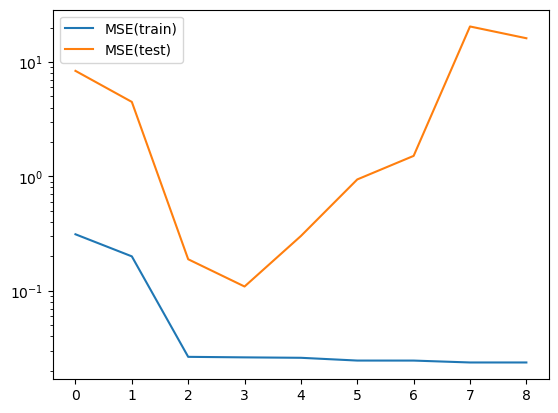

In [72]:
plt.plot(range(M), etrn, range(M), etst)
plt.yscale("log")
plt.legend(["MSE(train)","MSE(test)"])

Train data(70%)
Validation data(15%)
Test data(15%)


NOTE: in cell below we printed mse train and mse test, however our fit_model function returns mse train and mse validation so mse test here comes from the previous cell that why our mse tests are the same with previous cell.

In [73]:
q = 85
Ntrn = N*q//100
xtrn, ytrn = x[:Ntrn], y[:Ntrn]
xtst, ytst = x[:Ntrn], y[:Ntrn]
etrn = np.zeros(M)
evld = np.zeros(M)
p = [None for _ in range(M)]
for n in range(M):
    p[n], etrn[n], evld[n] = fit_model(xtrn, ytrn, n, 85)
print(pd.DataFrame(data = {'mse_train': etrn, 'mse_test': etst}))

   mse_train   mse_test
0   0.104911   8.365416
1   0.099616   4.478878
2   0.028269   0.188743
3   0.028131   0.109055
4   0.026873   0.301491
5   0.026397   0.940842
6   0.025423   1.511365
7   0.025384  20.436204
8   0.025373  16.126705


So if we want to have an correct output it should be like this

In [74]:
q = 85
Ntrn = N*q//100
xtrn, ytrn = x[:Ntrn], y[:Ntrn]
xtst, ytst = x[:Ntrn], y[:Ntrn]
etrn = np.zeros(M)
evld = np.zeros(M)
p = [None for _ in range(M)]
for n in range(M):
    p[n], etrn[n], evld[n] = fit_model(xtrn, ytrn, n, 85)
    etst[n] = mse(ytst, p[n](xtst))
print(pd.DataFrame(data = {'mse_train': etrn, 'mse_validation': evld, 'mse_test': etst}))

   mse_train  mse_validation  mse_test
0   0.104911        3.496257  0.623587
1   0.099616        2.851013  0.520418
2   0.028269        0.053980  0.032201
3   0.028131        0.022265  0.027234
4   0.026873        0.971847  0.171399
5   0.026397        0.040288  0.028522
6   0.025423       17.299875  2.667398
7   0.025384        3.681185  0.584506
8   0.025373        1.563454  0.260609


# HomeWork 1

# Q1
because it is not mentioend that we want to split the data to Train data(50%) and Test data(50%) or Train + Validation data(50%) and Test data(50%), we will do the both 

Train data(50%)     Test data(50%)

In [75]:
M = 9
etrn = np.zeros(M)
etst = np.zeros(M)
for m in range(M):
    p, etrn[m], etst[m] = fit_model(x, y, m, 50)
print(pd.DataFrame(data = {'mse_train': etrn, 'mse_test': etst}))

   mse_train      mse_test
0   0.071827  4.470751e+00
1   0.042290  7.820333e+00
2   0.027319  1.782403e-01
3   0.022829  5.373974e+01
4   0.022424  4.382807e+02
5   0.022205  1.932616e+03
6   0.021374  7.573873e+05
7   0.020336  3.689431e+07
8   0.020251  1.123683e+07


Train + Validation data(50%) and Test data(50%)

qtr = 85  ====>  Train data(42.5%)   Validation data(7.5%)   Test data(50%)

In [76]:
q = 50
Ntrn = N*q//100
xtrn, ytrn = x[:Ntrn], y[:Ntrn]
xtst, ytst = x[:Ntrn], y[:Ntrn]
etrn = np.zeros(M)
evld = np.zeros(M)
p = [None for _ in range(M)]
for n in range(M):
    p[n], etrn[n], evld[n] = fit_model(xtrn, ytrn, n, 85)
    etst[n] = mse(ytst, p[n](xtst))
print(pd.DataFrame(data = {'mse_train': etrn, 'mse_validation': evld, 'mse_test': etst}))

   mse_train  mse_validation   mse_test
0   0.081862        0.019252   0.071844
1   0.021414        0.312056   0.067917
2   0.021150        0.243213   0.056680
3   0.021075        0.181111   0.046681
4   0.021055        0.118980   0.036723
5   0.021054        0.102381   0.034066
6   0.020998        0.390463   0.080113
7   0.020697        8.616457   1.396018
8   0.018952      400.480149  64.092743


Train data(90%)     Test data(10%)

In [77]:
M = 9
etrn = np.zeros(M)
etst = np.zeros(M)
for m in range(M):
    p, etrn[m], etst[m] = fit_model(x, y, m, 90)
print(pd.DataFrame(data = {'mse_train': etrn, 'mse_test': etst}))

   mse_train   mse_test
0   0.777835  10.057676
1   0.332967   3.458503
2   0.029427   0.127315
3   0.027932   0.049804
4   0.027917   0.042321
5   0.026574   0.362102
6   0.026341   0.042895
7   0.025211   5.773412
8   0.025174   2.354900


Train + Validation data(90%) and Test data(10%)

qtr = 85  ====>  Train data(76.5%)   Validation data(13.5%)   Test data(10%)

In [78]:
q = 90
Ntrn = N*q//100
xtrn, ytrn = x[:Ntrn], y[:Ntrn]
xtst, ytst = x[:Ntrn], y[:Ntrn]
etrn = np.zeros(M)
evld = np.zeros(M)
p = [None for _ in range(M)]
for n in range(M):
    p[n], etrn[n], evld[n] = fit_model(xtrn, ytrn, n, 85)
    etst[n] = mse(ytst, p[n](xtst))
print(pd.DataFrame(data = {'mse_train': etrn, 'mse_validation': evld, 'mse_test': etst}))

   mse_train  mse_validation  mse_test
0   0.180925        4.736797  0.889616
1   0.143133        2.952853  0.580200
2   0.026979        0.103770  0.038925
3   0.026955        0.087723  0.036408
4   0.026137        0.330045  0.073412
5   0.025184        0.044756  0.028228
6   0.025026        0.416852  0.085977
7   0.024342        1.795143  0.299800
8   0.024341        2.219322  0.365782


Train data(95%)     Test data(5%)

In [79]:
M = 9
etrn = np.zeros(M)
etst = np.zeros(M)
for m in range(M):
    p, etrn[m], etst[m] = fit_model(x, y, m, 95)
print(pd.DataFrame(data = {'mse_train': etrn, 'mse_test': etst}))

   mse_train   mse_test
0   1.090040  12.050815
1   0.399384   3.664418
2   0.029996   0.163101
3   0.028268   0.067789
4   0.028263   0.073500
5   0.027978   0.035635
6   0.026600   0.337385
7   0.025551   1.731011
8   0.025289   0.558368


Train + Validation data(95%) and Test data(5%)

qtr = 85  ====>  Train data(80.75%)   Validation data(14.25%)   Test data(5%)

In [80]:
q = 95
Ntrn = N*q//100
xtrn, ytrn = x[:Ntrn], y[:Ntrn]
xtst, ytst = x[:Ntrn], y[:Ntrn]
etrn = np.zeros(M)
evld = np.zeros(M)
p = [None for _ in range(M)]
for n in range(M):
    p[n], etrn[n], evld[n] = fit_model(xtrn, ytrn, n, 85)
    etst[n] = mse(ytst, p[n](xtst))
print(pd.DataFrame(data = {'mse_train': etrn, 'mse_validation': evld, 'mse_test': etst}))

   mse_train  mse_validation  mse_test
0   0.312012        6.194761  1.240867
1   0.200079        3.038500  0.648250
2   0.026481        0.099812  0.038060
3   0.026204        0.064022  0.032175
4   0.025980        0.130891  0.042545
5   0.024574        0.249827  0.060140
6   0.024564        0.364928  0.078305
7   0.023644        1.978944  0.332376
8   0.023643        1.599711  0.272496


# Analysis of Q1:

The training MSE is small because the model fits the seen region well.

The test MSE is much higher because the model must extrapolate to unseen regions of x.

When validation data is also included, the same pattern remains — only the proportions of the splits change.

# Q2
random splitting

In [81]:
def fit_model_random(x, y, m, qtr=80):
    N = x.size
    Ntrn = int(N * qtr / 100)

    # Randomly shuffle the data
    idx = np.random.permutation(N)
    trn_idx = idx[:Ntrn]
    tst_idx = idx[Ntrn:]

    xtrn, ytrn = x[trn_idx], y[trn_idx]
    xtst, ytst = x[tst_idx], y[tst_idx]

    p = np.polynomial.polynomial.Polynomial.fit(xtrn, ytrn, m)

    etrn = mse(ytrn, p(xtrn))
    etst = mse(ytst, p(xtst))

    return p, etrn, etst

In [82]:
M = 9
etrn_rand = np.zeros(M)
etst_rand = np.zeros(M)

for m in range(M):
    p, etrn_rand[m], etst_rand[m] = fit_model_random(x, y, m, 80)

print(pd.DataFrame({'mse_train': etrn_rand, 'mse_test': etst_rand}))

   mse_train  mse_test
0   1.774160  0.947540
1   0.516641  0.577761
2   0.032345  0.042445
3   0.029407  0.028084
4   0.030021  0.025283
5   0.027387  0.032781
6   0.027646  0.030002
7   0.026265  0.036266
8   0.024377  0.041679


# Analysis of Q2:

All sets (train, validation, test) come from the same distribution.

The test MSE usually decreases compared to the sequential case, because the model no longer needs to extrapolate.

The difference between training and test MSE becomes smaller, indicating better generalization.